# Proyecto UCU

In [ ]:
import shutil
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Python para Análisis de Datos

#### Análisis de canciones de Spotify

## 1) Definición del Problema

Contamos con un dataset proveniente de Kaggle que se obtuvo utilizando la API de Spotify. Nuestro objetivo será procesarlo para obtener un dataset adecuado con el que se puedan visualizar de forma fácil las relaciones entre los atributos de las canciones.

## Paso 2: Recopilación de datos


Descarga del dataset con kagglehub y guardado en la carpeta _../data/raw_.

### Importación de los datos y creación del DataFrame


In [ ]:
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
os.makedirs("../data/raw", exist_ok=True)
shutil.copytree(path, "../data/raw", dirs_exist_ok=True)

display("Spotify Tracks Dataset descargado en: ../data/raw")

In [ ]:
df = pd.read_csv("../data/raw/dataset.csv")


Exploración de los campos del dataset:

|     Variable     | Definición                                                                                                                       | Key                                                                                                                |
|:----------------:|:---------------------------------------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------|
|   Unnamed: 0   | Índice del registro                                                                                                              |                                                                                                                    |
|     track_id     | Identificador único de la canción                                                                                                |                                                                                                                    |
|     artists      | Intérprete/s                                                                                                                     |                                                                                                                    |
|    album_name    | Nombre del álbum                                                                                                                 |                                                                                                                    |
|    track_name    | Nombre de la canción                                                                                                             |                                                                                                                    |
|    popularity    | Popularidad de la canción                                                                                                        | 0 = Menor popularidad, 100 = Mayor popularidad                                                                     |
|   duration_ms    | Duración de la canción en milisegundos                                                                                           |                                                                                                                    |
|     explicit     | Indica si la canción contiene contenido explícito                                                                                | False = No, True = Sí                                                                                              |
|   danceability   | Bailabilidad (o cualidad de bailable)                                                                                            | 0 = Menos bailable, 1 = Más bailable                                                                               |
|      energy      | Medida de la intensidad de la canción                                                                                            | 0 = Baja energía, 1 = Alta energía                                                                                 |
|       key        | Tonalidad en la que está la canción                                                                                              | 0 = C, 1 = C♯/D♭, 2 = D, 3 = D♯/E♭, 4 = E, 5 = F, 6 = F♯/G♭, 7 = G, 8 = G♯/A♭, 9 = A, 10 = A♯/B♭, 11 = B |
|     loudness     | Volumen de la canción en decibeles (dB)                                                                                          | Valores relativos al máximo digital (0dB)                                                                 |
|       mode       | Indica si la tonalidad de la canción está en modo mayor o menor                                                                  | 0 = Menor, 1 = Mayor                                                                                               |
|   speechiness    | Presencia de palabras habladas en la canción                                                                                     | 0 = Poco contenido hablado, 1 = Mucho contenido hablado                                                            |
|   acousticness   | Métrica musical que mide el nivel de confianza de que la canción utilice sonidos en vivo en lugar de procesados electrónicamente | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
| instrumentalness | Predice si una canción no contiene voces                                                                                         | 0 = Contiene voces, 1 = Instrumental                                                                               |
|     liveness     | Probabilidad de que la grabación haya sido realizada en vivo                                                                     | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
|     valence      | Medida que describe la positividad musical de una canción                                                                        | 0 = Más negativa/triste, 1 = Más positiva/alegre                                                                   |
|      tempo       | Tempo estimado de la canción en pulsaciones o beats por minuto (BPM)                                                             |                                                                                                                    |
|  time_signature  | Compás estimado de la canción                                                                                                    | 3 = 3/4, 4 = 4/4, 5 = 5/4                                                                                          |
|   track_genre    | Género musical de la canción                                                                                                     |                                                                                                                    |

El dataset contiene varios valores que provienen de modelos predictivos de Spotify, por lo que es posible que existan errores y es algo a tener en cuenta en el posterior análisis.

## Paso 3: Análisis Descriptivo

In [31]:
df

,id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


* Se observa que en la columna track_name hay 89741 valores únicos en un dataset con 114000 registros, pero no se trata de un error. Para una misma canción el dataset tiene una fila por cada género de la pista.

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

* 3 de las 21 columnas presentan un único dato null.
* El data type detectado para cada columna concuerda con el tipo de dato esperado en todos los casos, pero para las variables key, mode y time_signature podrían redefinirse como variables categóricas.
* La columna "Unnamed: 0" funciona como identificador.

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


* Se detectan algunas incongruencias como los mínimos iguales a 0.000 para duration_ms y tempo.
* Se procede a identificar la cantidad de valores "0" en cada columna

In [ ]:
(df == 0).sum().sort_values(ascending=False)

* En algunas de estas columnas, los valores iguales a "0" están dentro de lo esperado. Por ejemplo para mode que es una variable booleana, un valor de cero corresponde a una canción en tonalidad menor. Sin embargo, esto no tiene sentido para las columnas valence, tempo y danceability, por lo que es algo a considerar al utilizar estos campos para relacionarlos con el resto.
* Procedemos a buscar filas con datos nulos:

In [ ]:
df.isnull().sum()

In [ ]:
df[df.isnull().any(axis=1)]

* Los tres nulos en las columnas artists, album_name y track_name corresponden a la fila con id 65900.

* Continuamos buscando duplicados:

In [ ]:
df.duplicated()

* No se encontraron duplicados. Podemos extender la búsqueda filtrando la columna track_id para evaluar si hay dos canciones con diferente track_id pero igual contenido (la misma canción con los mismos valores pero asignada a dos track_id diferentes):

In [ ]:

df.duplicated(subset=df.columns.difference(['track_id'])).sum()

* Ninguna canción aparece más de una vez con diferente track_id.

## Paso 4: Limpieza de Datos



* Se eliminaron las 176 filas que presentaban un valor igual a 0 en al menos una de las variables tempo, danceability o valence ya que un valor cero en alguna de estas variables puede dificultar o distorsionar la comparación entre canciones.
* También se decidió eliminar la fila que contenia datos nulos por el mismo motivo.

In [36]:
df_clean = df.copy()

In [37]:
filas_cero = (
    (df_clean["tempo"] == 0) |
    (df_clean["danceability"] == 0) |
    (df_clean["valence"] == 0)
)

filas_cero.sum()

np.int64(176)

In [38]:
df_clean.drop(df_clean[filas_cero].index, inplace=True)


In [39]:
df_clean.drop(65900, axis=0, inplace=True)

* Dado que una canción puede aparecer tantas veces como el número de géneros registrados que tenga, se decide agrupar los valores de track_genre. De esta forma no se pierde información si se realiza un filtro de duplicados por track_id.

In [ ]:
generos_agrupados = df_clean.groupby('track_id')['track_genre'].apply(lambda x: list(x.unique()))
df_clean = df_clean.drop_duplicates(subset=['track_id']).drop(columns=['track_genre'])
df_clean = df_clean.merge(generos_agrupados, on='track_id')

## Paso 5: Análisis de Variables - EDA

#### Análisis de Variables Univariante Categóricas
Para este dataset, las variables categóricas son

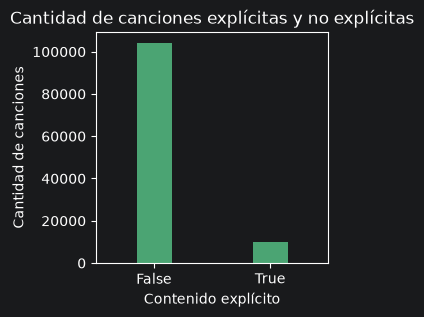

In [87]:
plt.figure(figsize=(3, 3))

sns.countplot(
    data=df_clean,
    x="explicit",
    color="mediumseagreen",
    width=0.3                # barras más finas
)

plt.title("Cantidad de canciones explícitas y no explícitas")
plt.xlabel("Contenido explícito")
plt.ylabel("Cantidad de canciones")

plt.show()

* Se observa una predominancia de canciones sin contenido explicito


In [75]:
variables = ["popularity", "duration_ms", "danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness", "valence", "tempo"]

correlacion = df_clean[variables].corr()

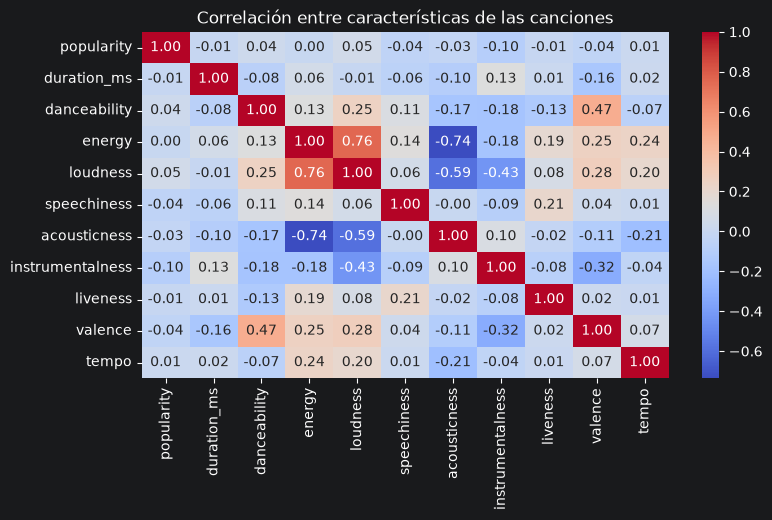

In [76]:
plt.figure(figsize=(8.5, 4.5))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlación entre características de las canciones")
plt.show()

* Se halló que las variables energy y loudness se encuentran relacionadas (0.76), lo que indicaría que las canciones con mas energía tienden a tener mayor intensidad sonora.
* También se observa una relación negativa entre energy y acousticness (-0.74), por lo que se entiende que las canciones más acústicas tienen menor energía.
 * Otra relación relevante es danceability con valence (0.47), lo que sugiere que las canciones más bailables suelen ser mas positivas.
  * La popularidad no muestra una dependencia significativa con ninguna de las otras variables (apenas una pequeña tendencia negativa (-0.10) con instrumentalness, indicando que el contenido "menos hablado" tiene menor tracción en la plataforma).

## Paso 6: Ingeniería de características
